# Hamiltonian Simulation by Generalized Quantum Signal Processing

In [1]:
from qualtran import Bloq, CompositeBloq, BloqBuilder, Signature, Register
from qualtran import QBit, QInt, QUInt, QAny
from qualtran.drawing import show_bloq, show_call_graph, show_counts_sigma
from typing import *
import numpy as np
import sympy
import cirq

In [2]:
from numpy.typing import NDArray
import scipy

from qualtran.bloqs.for_testing.matrix_gate import MatrixGate
from qualtran.bloqs.for_testing.random_select_and_prepare import random_qubitization_walk_operator
from qualtran.bloqs.hamiltonian_simulation.hamiltonian_simulation_by_gqsp import (
    _hubbard_time_evolution_by_gqsp,
    _symbolic_hamsim_by_gqsp,
    HamiltonianSimulationByGQSP,
)
from qualtran.bloqs.qsp.generalized_qsp_test import (
    assert_matrices_almost_equal,
    check_gqsp_polynomial_pair_on_random_points_on_unit_circle,
    verify_generalized_qsp,
)
from qualtran.bloqs.qubitization.qubitization_walk_operator import QubitizationWalkOperator
from qualtran.cirq_interop import BloqAsCirqGate
from qualtran.resource_counting import big_O, get_cost_value, QECGatesCost, QubitCount
from qualtran.symbolics import Shaped
def verify_hamiltonian_simulation_by_gqsp(
    W: QubitizationWalkOperator, H: NDArray[np.complex128], *, t: float, precision: float
):
    N = H.shape[0]

    W_e_iHt = HamiltonianSimulationByGQSP(W, t=t, precision=precision)
    # TODO This cirq.unitary call is 4-5x faster than tensor_contract.
    #      https://github.com/quantumlib/Qualtran/issues/1336
    # result_unitary = cirq.unitary(BloqAsCirqGate(W_e_iHt))
    result_unitary = W_e_iHt.tensor_contract()

    expected_top_left = scipy.linalg.expm(-1j * H * t)
    actual_top_left = result_unitary[:N, :N]
    assert_matrices_almost_equal(expected_top_left, actual_top_left, atol=1e-4)


select_bitsize = 1
target_bitsize = 2
t = 2
precision = 1e-5
random_state = np.random.RandomState(42)

W, H = random_qubitization_walk_operator(
    select_bitsize, target_bitsize, random_state=random_state
)

W_e_iHt = HamiltonianSimulationByGQSP(W, t=t, precision=precision)


In [3]:
%load_ext snakeviz

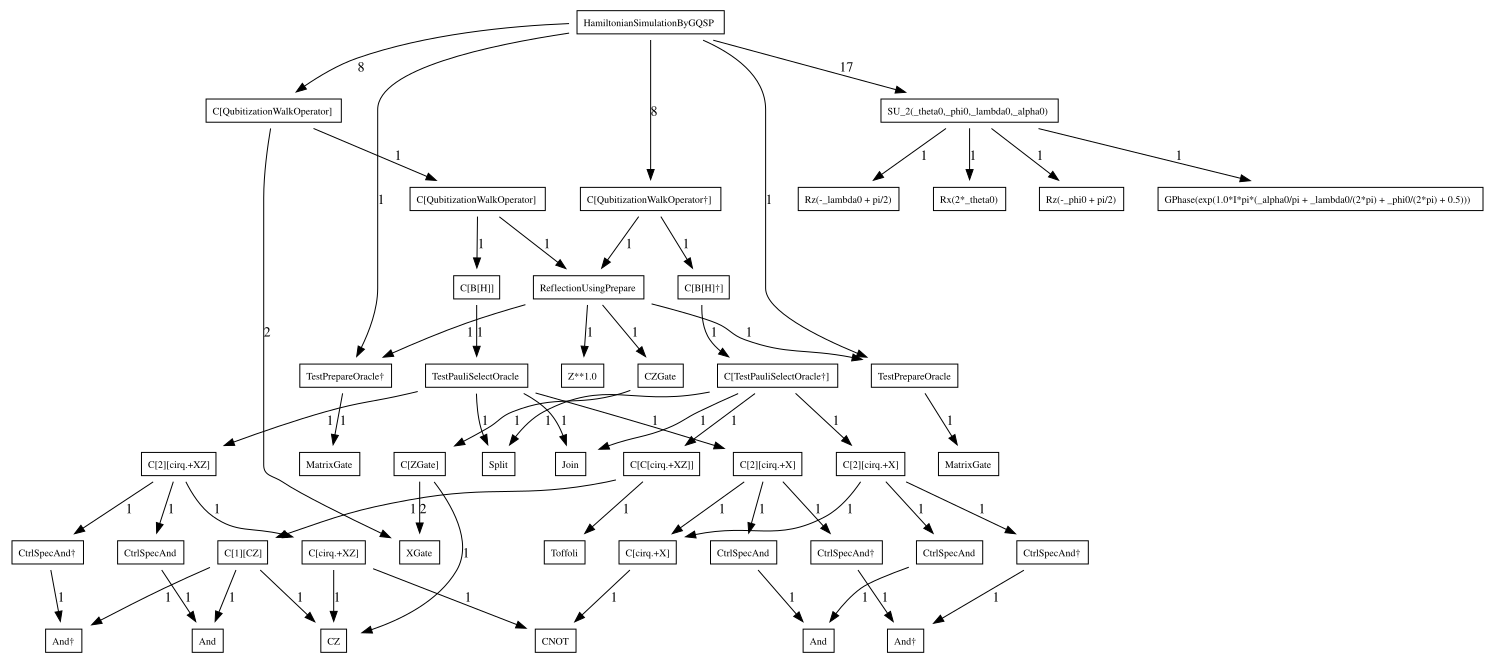

In [4]:
W_e_iHt = HamiltonianSimulationByGQSP(W, t=t, precision=precision)
g, _ = W_e_iHt.call_graph()
show_call_graph(g)

In [22]:
x = W_e_iHt.as_composite_bloq()

In [31]:
%%snakeviz
W_e_iHt.as_composite_bloq().flatten()

 
*** Profile stats marshalled to file '/var/folders/3l/4zd2bgl54gb8xfx5hn66g6fr00m48r/T/tmprafedakq'.
Embedding SnakeViz in this document...
<function display at 0x1047e18a0>


In [32]:
%%snakeviz
verify_hamiltonian_simulation_by_gqsp(W, H.matrix(), t=t, precision=precision)

tn contraction width 10.0
 
*** Profile stats marshalled to file '/var/folders/3l/4zd2bgl54gb8xfx5hn66g6fr00m48r/T/tmpz4r9espa'.
Embedding SnakeViz in this document...
<function display at 0x1047e18a0>


## `HamiltonianSimulationByGQSP`
Hamiltonian simulation using Generalized QSP given a qubitized quantum walk operator.

Given the Szegedy Quantum Walk Operator for a Hamiltonian $H$ constructed from SELECT and PREPARE oracles,
one can construct a block-encoding of $e^{-iHt}$ using GQSP (Corollary 8).

### Recap: Qubitization Walk Operator

For a Hamiltonian $H = \sum_j \alpha_j U_j$ where $U_j$ are unitaries and $\alpha_j \ge 0$,
we are given the SELECT and PREPARE oracles:
$$ \text{SELECT} = \sum_j |j\rangle\langle j| \otimes U_j $$
$$ \text{PREPARE} |0\rangle = \sum_j \frac{\sqrt{\alpha_j}}{\|\alpha\|_1} |j\rangle $$

We can then implement the [QubitizationWalkOperator](../qubitization_walk_operator.ipynb) that encodes the spectrum of $H$ in the eigenphases of the walk operator $W$.

### Approximating the function $e^{i\theta} \mapsto e^{it\cos\theta}$

We can use the [Jacobi-Anger expansion](https://en.wikipedia.org/wiki/Jacobi%E2%80%93Anger_expansion) to obtain low-degree polynomial approximations for the $\cos$ function:

$$
    e^{it\cos\theta} = \sum_{n = -\infty}^{\infty} i^n J_n(t) (e^{i\theta})^n
$$
where $J_n$ is the $n$-th [Bessel function of the first kind](https://en.wikipedia.org/wiki/Bessel_function#Bessel_functions_of_the_first_kind).

If we cut-off the above to terms upto degree $d$, we get

$$
    P[t](z) = \sum_{n = -d}^d i^n J_n(t) z^n
$$

Polynomial approximations of the above are provided in the [`qualtran.linalg.jacobi_anger_approximations`](../../linalg/jacobi_anger_approximations.py) module.

### Simulation: Block-encoding $e^{-iHt}$

As the eigenphases of the walk operator above are $e^{-i\arccos(E_k / \|\alpha\|_1)}$,
we can use the GQSP polynomial with $P = P[-\|\alpha\|_1 t]$ to obtain $P(U) = e^{-iHt}$.
The obtained GQSP operator $G$ can then be used with two calls to the PREPARE oracle to simulate the hamiltonian:

$$
    (I \otimes \text{PREPARE}^\dagger \otimes I) G (I \otimes \text{PREPARE} \otimes I) |0\rangle|0\rangle|\psi\rangle = |0\rangle|0\rangle e^{-iHt}|\psi\rangle
$$

This therefore block-encodes $e^{-iHt}$ in the block where the signal qubit and selection registers are all $|0\rangle$.

#### References
 - [Generalized Quantum Signal Processing](https://arxiv.org/abs/2308.01501). Motlagh and Wiebe. (2023). Theorem 7, Corollary 8. 

#### Parameters
 - `walk_operator`: qubitization walk operator of $H$ constructed from SELECT and PREPARE oracles.
 - `t`: time to simulate the Hamiltonian, i.e. $e^{-iHt}$
 - `precision`: the precision $\epsilon$ of the final block encoded $e^{-iHt}$. Split into two: half to approximate $e^{it\cos\theta}$ to a polynomial, and half to synthesize the underlying GQSP rotations.


In [ ]:
from qualtran.bloqs.hamiltonian_simulation.hamiltonian_simulation_by_gqsp import HamiltonianSimulationByGQSP

### Example Instances

In [ ]:
from qualtran.bloqs.chemistry.hubbard_model.qubitization import (
    get_walk_operator_for_hubbard_model,
)

walk_op = get_walk_operator_for_hubbard_model(2, 2, 1, 1)
hubbard_time_evolution_by_gqsp = HamiltonianSimulationByGQSP(walk_op, t=5, precision=1e-7)

In [ ]:
import sympy

from qualtran.bloqs.chemistry.hubbard_model.qubitization import (
    get_walk_operator_for_hubbard_model,
)

tau, t, inv_eps = sympy.symbols(r"\tau t \epsilon^{-1}", positive=True)
walk_op = get_walk_operator_for_hubbard_model(2, 2, tau, 4 * tau)
symbolic_hamsim_by_gqsp = HamiltonianSimulationByGQSP(walk_op, t=t, precision=1 / inv_eps)

#### Graphical Signature

In [ ]:
from qualtran.drawing import show_bloqs
show_bloqs([hubbard_time_evolution_by_gqsp, symbolic_hamsim_by_gqsp],
           ['`hubbard_time_evolution_by_gqsp`', '`symbolic_hamsim_by_gqsp`'])

### Call Graph

In [ ]:
from qualtran.resource_counting.generalizers import ignore_split_join
hubbard_time_evolution_by_gqsp_g, hubbard_time_evolution_by_gqsp_sigma = hubbard_time_evolution_by_gqsp.call_graph(max_depth=1, generalizer=ignore_split_join)
show_call_graph(hubbard_time_evolution_by_gqsp_g)
show_counts_sigma(hubbard_time_evolution_by_gqsp_sigma)

In [ ]:
from qualtran.resource_counting.generalizers import generalize_rotation_angle, ignore_split_join, ignore_alloc_free
_, symbolic_hamsim_by_gqsp_sigma = symbolic_hamsim_by_gqsp.call_graph(max_depth=2, generalizer=[ignore_split_join, ignore_alloc_free, generalize_rotation_angle])
show_counts_sigma(symbolic_hamsim_by_gqsp_sigma)